In [1]:
import plotly.graph_objects as go
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Probing Performance on MSA text

In [2]:
# Aggregate overall results from all JSON files in results_dialects into a single DataFrame
import os
import json
import glob
import pandas as pd


def load_overall_records(results_dir: str) -> pd.DataFrame:
    """Scan results_dialects/*.json and collect __OVERALL__ accuracy/f1 per layer.

    Columns:
      - source_file: JSON filename (traceability)
      - model: HF model id from file's top-level key
      - task: e.g., 'NER'
      - dialect: e.g., 'Egypt', 'MSA', ...
      - dataset: dataset name under the dialect
      - layer: 'layer_k' or 'all_layers'
      - accuracy_overall, f1_overall: scalar metrics if present
    """
    records = []
    json_files = glob.glob(os.path.join(results_dir, "*.json"))

    for path in json_files:
        try:
            with open(path, "r", encoding="utf-8") as f:
                text = f.read()
            # Normalize non-JSON tokens (NaN/Infinity) to valid JSON nulls
            text = (
                text.replace("NaN", "null")
                .replace("Infinity", "null")
                .replace("-Infinity", "null")
            )
            data = json.loads(text)
        except Exception as e:
            print(f"Skipping {os.path.basename(path)} due to parse error: {e}")
            continue

        source_file = os.path.basename(path)
        if not isinstance(data, dict):
            continue

        for model, task_dict in data.items():
            if not isinstance(task_dict, dict):
                continue
            for task, dialect_dict in task_dict.items():
                if not isinstance(dialect_dict, dict):
                    continue
                for dialect, dataset_dict in dialect_dict.items():
                    if not isinstance(dataset_dict, dict):
                        continue
                    for dataset, layers_dict in dataset_dict.items():
                        if not isinstance(layers_dict, dict):
                            continue
                        for layer, metrics in layers_dict.items():
                            if not isinstance(metrics, dict):
                                continue

                            acc = None
                            f1 = None
                            acc_dict = metrics.get("accuracy")
                            f1_dict = metrics.get("f1_score")
                            if isinstance(acc_dict, dict):
                                acc = acc_dict.get("__OVERALL__")
                            if isinstance(f1_dict, dict):
                                f1 = f1_dict.get("__OVERALL__")

                            if 'accuracy_selectivity' in metrics:
                                acc_selectivity = metrics.get('accuracy_selectivity')
                            else:
                                acc_selectivity = None

                            if 'f1_score_selectivity' in metrics:
                                f1_score_selectivity = metrics.get('f1_score_selectivity')
                            else:
                                f1_score_selectivity = None

                            if acc is not None or f1 is not None:
                                records.append(
                                    {
                                        "model": model,
                                        "task": task,
                                        "dialect": dialect,
                                        "dataset": dataset,
                                        "layer": layer,
                                        "accuracy_overall": acc,
                                        "f1_overall": f1,
                                        "accuracy_selectivity": acc_selectivity,
                                        "f1_score_selectivity": f1_score_selectivity,
                                    }
                                )

    return pd.DataFrame.from_records(records)


# Build the DataFrame
results_dir = "results/results_msa"
df_overall = load_overall_records(results_dir)

# Order rows and preview
if not df_overall.empty:
    def _layer_order(x: str) -> int:
        if x == "all_layers":
            return 10_000
        try:
            return int(str(x).split("_")[-1])
        except Exception:
            return 9_999

    df_overall["_order"] = df_overall["layer"].map(_layer_order)
    df_overall = (
        df_overall.sort_values(["model", "task", "dialect", "dataset", "_order"])\
                  .drop(columns=["_order"]).reset_index(drop=True)
    )

print(
    f"Aggregated {len(df_overall)} rows from {len(glob.glob(os.path.join(results_dir, '*.json')))} files."
)

df_overall.head(5)

df_overall = df_overall[df_overall['dataset'] != 'PADT_PUD']
df_overall = df_overall[~((df_overall['dataset'] == 'CLEANANERcorp') & (df_overall['dialect'] != 'MSA'))]

Aggregated 546 rows from 13 files.


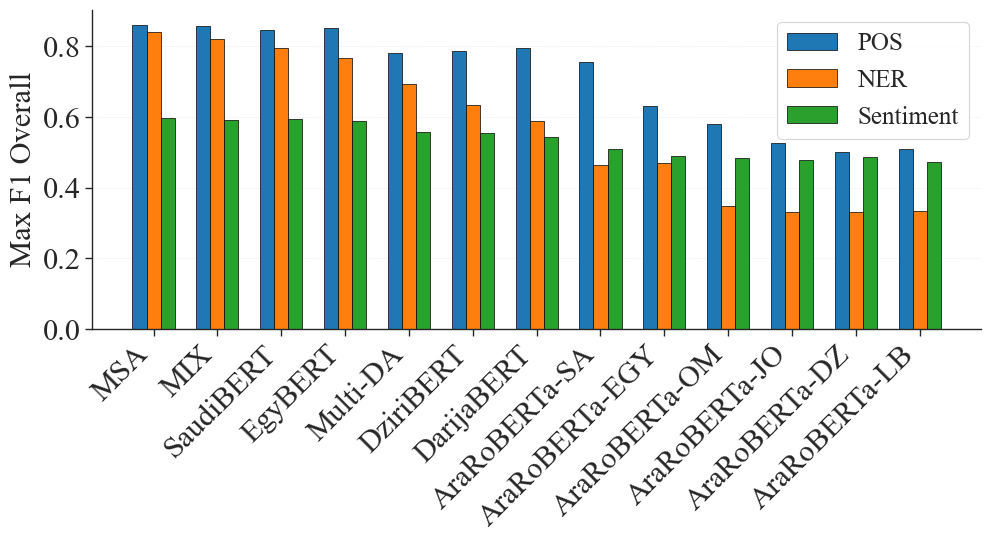

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_max_f1_three_tasks_combined(
    data: pd.DataFrame, 
    dialect: str, 
    tasks = ['POS', 'NER', 'Sentiment']
):
    sns.set_style('ticks')
    sns.set_context('paper', font_scale=1.0)

    plt.rcParams["font.family"] = "Times New Roman"
    
    # Nicer model names
    model_mapping = {
        'CAMeL-Lab/bert-base-arabic-camelbert-da': 'Multi-DA',
        'CAMeL-Lab/bert-base-arabic-camelbert-mix': 'MIX',
        'CAMeL-Lab/bert-base-arabic-camelbert-msa': 'MSA',
        'SI2M-Lab/DarijaBERT': 'DarijaBERT',
        'alger-ia/dziribert': 'DziriBERT',
        'faisalq/EgyBERT': 'EgyBERT',
        'faisalq/SaudiBERT': 'SaudiBERT',
        'reemalyami/AraRoBERTa-DZ': 'AraRoBERTa-DZ',
        'reemalyami/AraRoBERTa-EGY': 'AraRoBERTa-EGY',
        'reemalyami/AraRoBERTa-JO': 'AraRoBERTa-JO',
        'reemalyami/AraRoBERTa-LB': 'AraRoBERTa-LB',
        'reemalyami/AraRoBERTa-OM': 'AraRoBERTa-OM',
        'reemalyami/AraRoBERTa-SA': 'AraRoBERTa-SA'
    }

    # Replace HF names with short names but keep others untouched
    df_local = data.copy()
    df_local['model'] = df_local['model'].replace(model_mapping)

    # Filter and aggregate: max F1 per (model, task) for the given dialect
    df = df_local[
        (df_local['dialect'] == dialect) &
        (df_local['task'].isin(tasks)) &
        (df_local['layer'] != 'all_layers')
    ]

    df = (
        df
        .groupby(['model', 'task'], as_index=False)
        .agg({'f1_overall': 'max'})
    )

    # Pivot to models × tasks
    pivot = df.pivot(index='model', columns='task', values='f1_overall')

    # Ensure tasks appear in requested order (and drop missing cols silently)
    pivot = pivot[[t for t in tasks if t in pivot.columns]]

    # Sort models by average F1 (optional)
    pivot['mean_f1'] = pivot.mean(axis=1, skipna=True)
    pivot = pivot.sort_values('mean_f1', ascending=False)
    pivot = pivot.drop(columns=['mean_f1'])

    models = pivot.index.tolist()
    x = np.arange(len(models))
    n_tasks = len(pivot.columns)

    # Bar width and offsets so they’re centered around each model
    width = 0.22
    offsets = (np.arange(n_tasks) - (n_tasks - 1) / 2) * width

    fig, ax = plt.subplots(figsize=(10, 5.5))

    # Color palette for tasks
    colors = sns.color_palette('tab10', n_tasks)

    # Plot one bar-series per task
    for i, task in enumerate(pivot.columns):
        heights = pivot[task].values
        ax.bar(
            x + offsets[i],
            heights,
            width=width,
            label=task,
            color=colors[i],
            edgecolor='black',
            linewidth=0.5,
        )

    # Axes & labels
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=22)
    ax.set_ylabel('Max F1 Overall', fontsize=22)
    ax.tick_params(axis='y', labelsize=22)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)

    # ax.set_title(f'Max F1 per Model and Task – {dialect}', fontsize=11, fontweight='bold')

    # Legend for tasks
    # ax.legend(title='Task', fontsize=10, title_fontsize=10, loc='best')
    # ax.legend(fontsize=18, loc='best', ncol=len(ax.get_legend_handles_labels()[1]), columnspacing=0.85, handletextpad=0.3, frameon=True)
    ax.legend(fontsize=18, loc='best')

    sns.despine()
    plt.tight_layout()

    # Save as clear vector image (good for papers)
    plt.savefig(
        f'visualizations/max_f1_all_tasks_{dialect}.png',
        format='png',
        bbox_inches='tight',
        dpi=300,
    )
    plt.show()

plot_max_f1_three_tasks_combined(df_overall, dialect='MSA')

## Effect of Training Size

In [4]:
import re
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import spearmanr

def plot_size_proximity_1x3_acl(
    df: pd.DataFrame,
    model_col: str = "model",
    size_col: str = "size_in_B",
    f1_cols: list[str] = None,
    subplot_titles: list[str] = None,
    msa_baselines: list[float] | None = None,
    show_labels: bool = False,
    max_labels: int = 25,
    show_linear_fit: bool = True,
    pad_frac_x: float = 0.06,
    pad_frac_y: float = 0.06,
    clamp01_x: bool = False,
    clamp01_y: bool = False,
    edge_frac_x: float = 0.05,
    edge_frac_y: float = 0.08,
    extra_label_pad_x: float = 0.05,
    extra_label_pad_y: float = 0.08,
    x_axis_title: str = "Training Corpus Size (B words)",
    y_axis_titles: list[str] | None = None,
    title: str | None = None,
    output_format: str = "pdf",  # "pdf" or "svg" for ACL
    filename: str = None,
):
    """
    ACL-style three-panel plot with publication-ready formatting.

    Key ACL modifications:
    - Two-column width: 6.5 inches (16.4 cm)
    - Font: Times New Roman, readable sizes (10-11pt)
    - Grayscale-friendly with distinct markers
    - Minimal styling for print quality
    - Vector output (PDF/SVG)
    """

    # ACL dimensions for two-column figure
    ACL_WIDTH_INCHES = 5.5
    ACL_HEIGHT_INCHES = 2.5

    FONT_FAMILY = "Times New Roman, Times, serif"
    FONT_SIZE_AXIS_LABEL = 45
    FONT_SIZE_TICK = 45
    FONT_SIZE_TITLE = 45
    FONT_SIZE_ANNOTATION = 45

    MARKER_SYMBOLS = ["circle"]
    MARKER_SIZE = 20
    LINE_WIDTH = 5

    COLORS_GRAY = ["#000000"]

    # Defaults
    if f1_cols is None:
        f1_cols = ["pos_probe_score", "ner_probe_score", "sentiment_probe_score"]
    assert len(f1_cols) == 3, "f1_cols must have length 3."

    if subplot_titles is None:
        subplot_titles = ["POS", "NER", "Sentiment"]
    assert len(subplot_titles) == 3, "subplot_titles must have length 3."

    if y_axis_titles is None:
        y_axis_titles = [
            "Probe F1 (POS)",
            "Probe F1 (NER)",
            "Probe F1 (Sentiment)",
        ]
    assert len(y_axis_titles) == 3, "y_axis_titles must have length 3."

    if msa_baselines is not None:
        assert len(msa_baselines) == 3, "msa_baselines must have length 3 or be None."

    COMMON_Y_TITLE = "Probe Max-F1"  # <-- CHANGED: single shared y-axis title text

    def _padded_range(series: pd.Series, pad: float, clamp01: bool):
        s = pd.to_numeric(series, errors="coerce").dropna()
        if s.empty:
            return None
        vmin, vmax = float(s.min()), float(s.max())
        if not np.isfinite(vmin) or not np.isfinite(vmax):
            return None
        if np.isclose(vmin, vmax):
            span = max(abs(vmin), 1.0) * pad
            lo, hi = vmin - span, vmax + span
        else:
            span = vmax - vmin
            lo, hi = vmin - span * pad, vmax + span * pad
        if clamp01:
            lo, hi = max(0.0, lo), min(1.0, hi)
            if hi - lo < 1e-6:
                mid = (vmin + vmax) / 2.0
                lo, hi = max(0.0, mid - 0.05), min(1.0, mid + 0.05)
        return [lo, hi]

    def _expand_range(rng, extra_x=0.0, extra_y=0.0, which="x"):
        if rng is None:
            return None
        lo, hi = rng
        span = max(hi - lo, 1e-12)
        return [
            lo - span * (extra_x if which == "x" else extra_y),
            hi + span * (extra_x if which == "x" else extra_y),
        ]

    def _edge_aware_positions(xs, ys, xr, yr, edge_x=0.05, edge_y=0.08):
        xlo, xhi = xr
        ylo, yhi = yr
        xspan = max(xhi - xlo, 1e-9)
        yspan = max(yhi - ylo, 1e-9)
        pos = []
        for x, y in zip(xs, ys):
            v = "top"
            h = "center"
            if y >= yhi - edge_y * yspan:
                v = "bottom"
            elif y <= ylo + edge_y * yspan:
                v = "top"
            if x >= xhi - edge_x * xspan:
                h = "left"
            elif x <= xlo + edge_x * xspan:
                h = "right"
            pos.append(f"{v} {h}")
        return pos

    # Prep data
    cols_needed = [model_col, size_col] + f1_cols
    data = df[cols_needed].copy()
    data[size_col] = pd.to_numeric(data[size_col], errors="coerce")
    for c in f1_cols:
        data[c] = pd.to_numeric(data[c], errors="coerce")
    data = data.dropna(subset=[size_col])

    all_models = data[model_col].astype(str).unique().tolist()

    camel_pat = re.compile(r"camel", flags=re.IGNORECASE)
    araro_pat = re.compile(r"\bara-?roberta\b", flags=re.IGNORECASE)

    def group_name(m: str) -> str:
        if camel_pat.search(m):
            return "CAMeL-Lab models"
        elif araro_pat.search(m):
            return "AraRoBERTa models"
        else:
            return "Other models"

    def group_priority(m: str) -> int:
        g = group_name(m)
        if g == "CAMeL-Lab models":
            return 0
        elif g == "Other models":
            return 1
        else:
            return 2

    models_sorted = sorted(all_models, key=lambda m: (group_priority(m), m.lower()))
    marker_map = {m: MARKER_SYMBOLS[i % len(MARKER_SYMBOLS)]
                  for i, m in enumerate(models_sorted)}
    color_map = {m: COLORS_GRAY[i % len(COLORS_GRAY)]
                 for i, m in enumerate(models_sorted)}

    legend_seen: set[str] = set()
    legendgroup_titles_seen: set[str] = set()

    colors = sns.color_palette('tab10').as_hex()

    fig = make_subplots(
        rows=1, cols=3,
        shared_xaxes=False,
        shared_yaxes=False,
        column_widths=[0.33, 0.33, 0.34],
        horizontal_spacing=0.07,
        subplot_titles=subplot_titles,
    )

    def _panel(col_idx: int, f1_col: str, y_title: str, msa_baseline_val: float | None):
        nonlocal legend_seen, legendgroup_titles_seen

        sub = data[[model_col, size_col, f1_col]].dropna(subset=[f1_col]).copy()
        if sub.empty:
            fig.add_annotation(
                text="No data",
                showarrow=False,
                font=dict(size=FONT_SIZE_ANNOTATION, color="gray", family=FONT_FAMILY),
                xref=f"x{col_idx} domain", yref=f"y{col_idx} domain",
                x=0.5, y=0.5,
            )
            return

        xx = sub[size_col].values
        yy = sub[f1_col].values

        x_fit = y_fit = np.array([])
        if show_linear_fit and len(xx) >= 2 and np.isfinite(xx).all() and np.isfinite(yy).all():
            coef = np.polyfit(xx, yy, 1)
            x_fit = np.linspace(xx.min(), xx.max(), 200)
            y_fit = np.polyval(coef, x_fit)

        x_range = _padded_range(sub[size_col], pad_frac_x, clamp01_x)
        y_series = sub[f1_col].copy()
        if msa_baseline_val is not None and np.isfinite(msa_baseline_val):
            y_series = pd.concat([y_series, pd.Series([float(msa_baseline_val)])], ignore_index=True)
        y_range = _padded_range(y_series, pad_frac_y, clamp01_y)

        use_labels = bool(show_labels and len(sub) <= max_labels)
        if use_labels:
            x_range = _expand_range(x_range, extra_x=extra_label_pad_x, which="x")
            y_range = _expand_range(y_range, extra_y=extra_label_pad_y, which="y")

        models_sorted_panel = sorted(
            sub[model_col].astype(str).unique(),
            key=lambda m: (group_priority(m), m.lower())
        )

        for mdl in models_sorted_panel:
            grp = sub[sub[model_col] == mdl]
            if grp.empty:
                continue

            xs = grp[size_col].values
            ys = grp[f1_col].values

            gname = group_name(mdl)
            showlg = mdl not in legend_seen
            if showlg:
                legend_seen.add(mdl)

            legendgrouptitle = None
            if gname not in legendgroup_titles_seen:
                legendgrouptitle = dict(text=gname, font=dict(size=FONT_SIZE_TICK))
                legendgroup_titles_seen.add(gname)

            textpos = None
            if use_labels and x_range and y_range:
                textpos = _edge_aware_positions(
                    xs, ys, x_range, y_range,
                    edge_x=edge_frac_x, edge_y=edge_frac_y,
                )

            fig.add_trace(
                go.Scatter(
                    x=xs,
                    y=ys,
                    mode="markers+text" if use_labels else "markers",
                    text=grp[model_col] if use_labels else None,
                    textposition=textpos if use_labels else None,
                    textfont=dict(size=FONT_SIZE_ANNOTATION, family=FONT_FAMILY),
                    name=str(mdl),
                    legendgroup=gname,
                    legendgrouptitle=legendgrouptitle,
                    showlegend=showlg,
                    marker=dict(
                        size=MARKER_SIZE,
                        color=colors[0],
                        symbol=marker_map.get(str(mdl), "circle"),
                        line=dict(width=0.5, color="#000000"),
                    ),
                    cliponaxis=True,
                    hovertemplate=(
                        f"{size_col}: %{{x:.3f}}<br>"
                        f"{f1_col}: %{{y:.3f}}<br>"
                        f"{model_col}: {mdl}<extra></extra>"
                    ),
                ),
                row=1, col=col_idx
            )

        if x_fit.size:
            fig.add_trace(
                go.Scatter(
                    x=x_fit,
                    y=y_fit,
                    mode="lines",
                    line=dict(width=LINE_WIDTH, color=colors[3], dash="dash"),
                    name="",
                    showlegend=False,
                    hoverinfo="skip",
                ),
                row=1, col=col_idx
            )

        if msa_baseline_val is not None and np.isfinite(msa_baseline_val):
            fig.add_hline(
                y=float(msa_baseline_val),
                line_width=1,
                line_dash="dot",
                line_color="#666666",
                annotation_text=f"MSA: {msa_baseline_val:.3f}",
                annotation_position="top left",
                annotation_font=dict(size=FONT_SIZE_ANNOTATION, family=FONT_FAMILY),
                row=1, col=col_idx
            )

        fig.update_xaxes(
            title_text=x_axis_title if col_idx == 2 else "",
            title_font=dict(size=FONT_SIZE_AXIS_LABEL, family=FONT_FAMILY),
            range=x_range,
            showline=True,
            linewidth=1,
            linecolor="black",
            mirror=True,
            showgrid=False,
            zeroline=False,
            ticks="outside",
            tickfont=dict(size=FONT_SIZE_TICK, family=FONT_FAMILY),
            row=1, col=col_idx
        )
        fig.update_yaxes(
            title_text='',  # <-- CHANGED: remove per-panel y-axis titles (we add one shared title instead)
            title_font=dict(size=FONT_SIZE_AXIS_LABEL, family=FONT_FAMILY),
            range=y_range,
            showline=True,
            linewidth=1,
            linecolor="black",
            mirror=True,
            showgrid=True,
            gridwidth=0.5,
            gridcolor="lightgray",
            zeroline=False,
            ticks="outside",
            tickfont=dict(size=FONT_SIZE_TICK, family=FONT_FAMILY),
            row=1, col=col_idx
        )

    for i, f1_col in enumerate(f1_cols, start=1):
        baseline = None
        if msa_baselines is not None:
            baseline = msa_baselines[i - 1]
        _panel(i, f1_col, y_axis_titles[i - 1], baseline)

    fig.update_layout(
        width=ACL_WIDTH_INCHES * 300,
        height=ACL_HEIGHT_INCHES * 300,
        margin=dict(l=85, r=10, t=45, b=50),  # <-- CHANGED: increase left margin to fit shared y-title
        plot_bgcolor="white",
        paper_bgcolor="white",
        title=dict(
            text=title,
            x=0.45,
            xanchor="center",
            font=dict(size=FONT_SIZE_TITLE, family=FONT_FAMILY, color="black")
        ),
        font=dict(family=FONT_FAMILY, size=FONT_SIZE_TICK, color="black"),
        showlegend=False,
        hovermode="closest",
    )

    # <-- CHANGED: add one shared y-axis title for the whole figure (paper coords)
    fig.add_annotation(
        text=COMMON_Y_TITLE,
        xref="paper", yref="paper",
        x=-0.1, 
        y=0.5,
        textangle=-90,
        showarrow=False,
        font=dict(size=FONT_SIZE_AXIS_LABEL, family=FONT_FAMILY, color="black"),
        align="center",
    )

    for annotation in fig.layout.annotations:
        if annotation.text in subplot_titles:
            annotation.update(font=dict(size=FONT_SIZE_TITLE, family=FONT_FAMILY),
                              text=f"<b>{annotation.text}</b>",)

    fig.show()

    if filename:
        if output_format.lower() == "pdf":
            fig.write_image(filename, format="pdf", width=ACL_WIDTH_INCHES*300,
                            height=ACL_HEIGHT_INCHES*300, scale=2)
            print(f"Saved as PDF: {filename}")
        elif output_format.lower() == "svg":
            fig.write_image(filename, format="svg", width=ACL_WIDTH_INCHES*300,
                            height=ACL_HEIGHT_INCHES*300)
            print(f"Saved as SVG: {filename}")
        elif output_format.lower() == "png":
            fig.write_image(filename, format="png", width=ACL_WIDTH_INCHES*300,
                            height=ACL_HEIGHT_INCHES*300)
            print(f"Saved as PNG: {filename}")



def get_size_df(data, tasks = ['POS', 'NER', 'Sentiment'], dialect='MSA'):

    # Replace HF names with short names but keep others untouched
    df_local = data.copy()

    # Filter and aggregate: max F1 per (model, task) for the given dialect
    df = df_local[
        (df_local['dialect'] == dialect) &
        (df_local['task'].isin(tasks)) &
        (df_local['layer'] != 'all_layers')
    ]

    df = (
        df
        .groupby(['model', 'task'], as_index=False)
        .agg({'f1_overall': 'max'})
    )

    # Pivot to models × tasks
    pivot = df.pivot(index='model', columns='task', values='f1_overall')

    # Ensure tasks appear in requested order (and drop missing cols silently)
    pivot = pivot[[t for t in tasks if t in pivot.columns]]

    pos_probe_score = pivot['POS'].to_dict()

    ner_probe_score = pivot['NER'].to_dict()

    sentiment_probe_score = pivot['Sentiment'].to_dict()

    size = {'CAMeL-Lab/bert-base-arabic-camelbert-msa': 12.6, 
            'CAMeL-Lab/bert-base-arabic-camelbert-mix': 17.3, 
            'faisalq/EgyBERT': 1.07, 
            'faisalq/SaudiBERT': 2.7, 
            'SI2M-Lab/DarijaBERT': 0.1, 
            'alger-ia/dziribert': 0.02, 
            'CAMeL-Lab/bert-base-arabic-camelbert-da': 5.8, 
            'reemalyami/AraRoBERTa-SA': 0.0454, 
            'reemalyami/AraRoBERTa-EGY': 0.0372, 
            'reemalyami/AraRoBERTa-OM': 0.0038, 
            'reemalyami/AraRoBERTa-JO': 0.0026, 
            'reemalyami/AraRoBERTa-LB': 0.0036, 
            'reemalyami/AraRoBERTa-DZ': 0.0019}

    size_df = pd.DataFrame({
        'model' : list(size.keys()),
        'size_in_B' : list(size.values()),
        'pos_probe_score' : [pos_probe_score[i] for i in size.keys()],
        'ner_probe_score' : [ner_probe_score[i] for i in size.keys()],
        'sentiment_probe_score' : [sentiment_probe_score[i] for i in size.keys()],
    })

    size_df['size_in_B_norm'] = size_df['size_in_B'].rank(pct=True)
    
    return size_df

size_df = get_size_df(df_overall, dialect='MSA')
plot_size_proximity_1x3_acl(
    df=size_df,
    model_col='model',
    size_col='size_in_B_norm',
    f1_cols=['pos_probe_score', 'ner_probe_score', 'sentiment_probe_score'],
    subplot_titles=['POS', 'NER', 'Sentiment'],
    msa_baselines=None,  # or [pos_msa, ner_msa, sent_msa] if you have them
    show_labels=False,
    # width=1500,
    x_axis_title='Number of Tokens (Percentile Rank)',
    y_axis_titles=[
        'Probe Max-F1',
        '',
        ''
    ],
    # title='Effect of Pretraining Corpus Size on Probe Performance'
    filename='visualizations/size_proximity_acl_style.png',
    output_format='png'
)

Saved as PNG: visualizations/size_proximity_acl_style.png


# Probing Performance on Dialectal Text

In [5]:
# Aggregate overall results from all JSON files in results_dialects into a single DataFrame
import os
import json
import glob
import pandas as pd


def load_overall_records(results_dir: str) -> pd.DataFrame:
    """Scan results_dialects/*.json and collect __OVERALL__ accuracy/f1 per layer.

    Columns:
      - source_file: JSON filename (traceability)
      - model: HF model id from file's top-level key
      - task: e.g., 'NER'
      - dialect: e.g., 'Egypt', 'MSA', ...
      - dataset: dataset name under the dialect
      - layer: 'layer_k' or 'all_layers'
      - accuracy_overall, f1_overall: scalar metrics if present
    """
    records = []
    json_files = glob.glob(os.path.join(results_dir, "*.json"))

    for path in json_files:
        try:
            with open(path, "r", encoding="utf-8") as f:
                text = f.read()
            # Normalize non-JSON tokens (NaN/Infinity) to valid JSON nulls
            text = (
                text.replace("NaN", "null")
                .replace("Infinity", "null")
                .replace("-Infinity", "null")
            )
            data = json.loads(text)
        except Exception as e:
            print(f"Skipping {os.path.basename(path)} due to parse error: {e}")
            continue

        source_file = os.path.basename(path)
        if not isinstance(data, dict):
            continue

        for model, task_dict in data.items():
            if not isinstance(task_dict, dict):
                continue
            for task, dialect_dict in task_dict.items():
                if not isinstance(dialect_dict, dict):
                    continue
                for dialect, dataset_dict in dialect_dict.items():
                    if not isinstance(dataset_dict, dict):
                        continue
                    for dataset, layers_dict in dataset_dict.items():
                        if not isinstance(layers_dict, dict):
                            continue
                        for layer, metrics in layers_dict.items():
                            if not isinstance(metrics, dict):
                                continue

                            acc = None
                            f1 = None
                            acc_dict = metrics.get("accuracy")
                            f1_dict = metrics.get("f1_score")
                            if isinstance(acc_dict, dict):
                                acc = acc_dict.get("__OVERALL__")
                            if isinstance(f1_dict, dict):
                                f1 = f1_dict.get("__OVERALL__")

                            if 'accuracy_selectivity' in metrics:
                                acc_selectivity = metrics.get('accuracy_selectivity')
                            else:
                                acc_selectivity = None

                            if 'f1_score_selectivity' in metrics:
                                f1_score_selectivity = metrics.get('f1_score_selectivity')
                            else:
                                f1_score_selectivity = None

                            if acc is not None or f1 is not None:
                                records.append(
                                    {
                                        "model": model,
                                        "task": task,
                                        "dialect": dialect,
                                        "dataset": dataset,
                                        "layer": layer,
                                        "accuracy_overall": acc,
                                        "f1_overall": f1,
                                        "accuracy_selectivity": acc_selectivity,
                                        "f1_score_selectivity": f1_score_selectivity,
                                    }
                                )

    return pd.DataFrame.from_records(records)


# Build the DataFrame
results_dir = "results/results_dialects_balanced"
df_overall_balanced = load_overall_records(results_dir)

# Order rows and preview
if not df_overall_balanced.empty:
    def _layer_order(x: str) -> int:
        if x == "all_layers":
            return 10_000
        try:
            return int(str(x).split("_")[-1])
        except Exception:
            return 9_999

    df_overall_balanced["_order"] = df_overall_balanced["layer"].map(_layer_order)
    df_overall_balanced = (
        df_overall_balanced.sort_values(["model", "task", "dialect", "dataset", "_order"])\
                  .drop(columns=["_order"]).reset_index(drop=True)
    )

print(
    f"Aggregated {len(df_overall_balanced)} rows from {len(glob.glob(os.path.join(results_dir, '*.json')))} files."
)

df_overall_balanced.head(5)
df_overall_balanced = df_overall_balanced[df_overall_balanced['dataset'] != 'PADT_PUD']
df_overall_balanced = df_overall_balanced[~((df_overall_balanced['dataset'] == 'CLEANANERcorp') & (df_overall_balanced['dialect'] != 'MSA'))]

Aggregated 1428 rows from 13 files.


In [6]:
import plotly.graph_objects as go
import pandas as pd
from plotly.subplots import make_subplots

import plotly.graph_objects as go
import pandas as pd
from plotly.subplots import make_subplots

def _compute_best_layer_diff(data: pd.DataFrame, task: str, compare_model: str) -> pd.DataFrame:
    """Internal helper to compute stats."""
    df = data[
        (data['task'] == task)
        & (data['layer'] != 'all_layers')
        & (data['dialect'] != 'MSA')
    ].copy()

    msa_df = df[df['model'] == compare_model].copy()
    msa_best = (
        msa_df.groupby(['dialect', 'dataset'], as_index=False)
        .apply(lambda x: x.loc[x['f1_overall'].idxmax()])
        .reset_index(drop=True)
        .rename(columns={'f1_overall': 'msa_best_f1', 'layer': 'msa_best_layer'})
    )
    msa_best.drop(columns=['model'], inplace=True)

    dialect_df = df[df['model'] != compare_model].copy()
    dialect_best = (
        dialect_df.groupby(['model', 'dialect', 'dataset'], as_index=False)
        .apply(lambda x: x.loc[x['f1_overall'].idxmax()])
        .reset_index(drop=True)
        .rename(columns={'f1_overall': 'dialect_best_f1', 'layer': 'dialect_best_layer'})
    )

    dialect_best = dialect_best[~dialect_best['model'].str.contains('CAMeL-Lab')]
    merged = dialect_best.merge(msa_best, on=['dialect', 'dataset'], how='inner')
    merged['difference'] = (
        (merged['dialect_best_f1'] - merged['msa_best_f1']) / merged['dialect_best_f1']
    )

     # Nicer model names
    model_mapping = {
        'CAMeL-Lab/bert-base-arabic-camelbert-da': 'CAMeLBERT-DA',
        'CAMeL-Lab/bert-base-arabic-camelbert-mix': 'CAMeLBERT-MIX',
        'CAMeL-Lab/bert-base-arabic-camelbert-msa': 'CAMeLBERT-MSA',
        'SI2M-Lab/DarijaBERT': 'DarijaBERT',
        'alger-ia/dziribert': 'DziriBERT',
        'faisalq/EgyBERT': 'EgyBERT',
        'faisalq/SaudiBERT': 'SaudiBERT',
        'reemalyami/AraRoBERTa-DZ': 'AraRoBERTa-DZ',
        'reemalyami/AraRoBERTa-EGY': 'AraRoBERTa-EGY',
        'reemalyami/AraRoBERTa-JO': 'AraRoBERTa-JO',
        'reemalyami/AraRoBERTa-LB': 'AraRoBERTa-LB',
        'reemalyami/AraRoBERTa-OM': 'AraRoBERTa-OM',
        'reemalyami/AraRoBERTa-SA': 'AraRoBERTa-SA'
    }

    sort_vals = ['EgyBERT','DziriBERT', 'SaudiBERT', 'DarijaBERT', 
                 'AraRoBERTa-SA','AraRoBERTa-EGY','AraRoBERTa-OM', 
                 'AraRoBERTa-LB','AraRoBERTa-JO','AraRoBERTa-DZ']

    merged['model'] = merged['model'].replace(model_mapping)

    agg = (
        merged.groupby('model', as_index=False)
        .agg({'difference': 'mean', 'dialect_best_f1': 'mean', 'msa_best_f1': 'mean'})
        # .sort_values('difference', ascending=False)
    )

    agg['model'] = pd.Categorical(
        agg['model'],
        categories=sort_vals,
        ordered=True
    )

    agg_sorted = agg.sort_values('model', ascending=False)   

    return agg_sorted

def plot_multi_baseline_comparison(
    data: pd.DataFrame,
    baselines: dict,
    tasks=('POS', 'NER', 'Sentiment')
):
    # --- Style Config ---
    font_family = "Times New Roman"
    colors = sns.color_palette('tab10').as_hex()
    styles = {
        'MSA': {'color': colors[3], 'symbol': 'circle', 'label': 'MSA'},
        'DA':  {'color': colors[0], 'symbol': 'square',  'label': 'Multi-DA'},
        'Mix': {'color': colors[2], 'symbol': 'diamond', 'label': 'MIX'},
    }
    
    # 1. Prepare Data
    plot_data = {} 
    # Calculate sort order based on the first task
    first_key = list(baselines.keys())[0]
    first_task_agg = _compute_best_layer_diff(data, tasks[0], baselines[first_key])
    # model_order = first_task_agg.sort_values('difference', ascending=True)['model'].tolist()
    model_order = first_task_agg['model'].tolist()

    for task in tasks:
        plot_data[task] = {}
        for label, model_name in baselines.items():
            plot_data[task][label] = _compute_best_layer_diff(data, task, model_name)

    # 2. Setup Figure
    fig = make_subplots(
        rows=1, cols=len(tasks),
        shared_yaxes=True,
        horizontal_spacing=0.05,
        subplot_titles=[f"<b>{t}</b>" for t in tasks]
    )

    # 3. Plotting Loop
    for col_idx, task in enumerate(tasks, start=1):
        
        for b_label, b_model_name in baselines.items():
            df = plot_data[task][b_label]
            df = df.set_index('model').reindex(model_order).reset_index()
            style = styles[b_label]
            
            show_legend = (col_idx == 1)

            fig.add_trace(
                go.Scatter(
                    x=df['difference'],
                    y=df['model'],
                    mode='markers',
                    name=style['label'],
                    legendgroup=b_label,
                    showlegend=show_legend,
                    marker=dict(
                        symbol=style['symbol'],
                        color=style['color'],
                        size=10,
                        line=dict(color='black', width=0.5)
                    ),
                    hovertemplate=(
                        f"<b>%{{y}}</b> ({style['label']})<br>" +
                        "ΔF1: %{x:.3%}<br>" +
                        "<extra></extra>"
                    )
                ),
                row=1, col=col_idx
            )

        # 4. Axis Styling (Native Zero Line)
        fig.update_xaxes(
            # --- FORCE LINE AT 0 ---
            zeroline=True,            
            zerolinecolor='black',
            zerolinewidth=2,
            
            showgrid=True,
            gridcolor="rgba(0,0,0,0.05)",
            showline=True, linewidth=1, linecolor='black', mirror=True,
            ticks='outside',
            tickfont=dict(family=font_family, size=18),
            # tickformat="",
            row=1, col=col_idx,
            )
        
        fig.update_yaxes(
            showgrid=False,
            showline=True, linewidth=1, linecolor='black', mirror=True,
            ticks='outside',
            tickfont=dict(family=font_family, size=35),
            gridcolor="rgba(0,0,0,0.1)",
            gridwidth=1,
            griddash='dot',
            row=1, col=col_idx        )

    # 5. Final Layout
    fig.update_layout(
        font=dict(family=font_family, color='black', size=35),
        width=1100,
        height=700,
        margin=dict(l=150, r=20, t=50, b=95),
        plot_bgcolor="white",
        paper_bgcolor="white",
        legend=dict(
            orientation="h",
            yanchor="bottom", y=1.10,
            xanchor="center", x=0.5,
            bgcolor="rgba(255,255,255,0.8)",
            bordercolor="black",
            borderwidth=0.5,
        )
    )
    
    fig.add_annotation(
        text="Relative F1 performace over General Arabic Models",
        x=0.5, y=-0.20,
        xref="paper", yref="paper",
        showarrow=False,
        font=dict(family=font_family, size=35)
    )
    
    # Update subplot title fonts
    for annotation in fig.layout.annotations:
        if annotation.text in [f"<b>{t}</b>" for t in tasks]:
            annotation.font.family = font_family
            annotation.font.size=35

    # fig.write_image("dialetal_data_performance.svg")
    fig.write_image(
        "visualizations/dialectal_data_performance.png",
        format="png",
        scale=3,              # 1100*3 by 500*3
        engine="kaleido",
    )

    fig.show()

# --- Usage ---
baselines = {
    'MSA': 'CAMeL-Lab/bert-base-arabic-camelbert-msa',
    'DA':  'CAMeL-Lab/bert-base-arabic-camelbert-da',
    'Mix': 'CAMeL-Lab/bert-base-arabic-camelbert-mix'
}

plot_multi_baseline_comparison(df_overall_balanced, baselines=baselines)


# Representation Similarity Analysis (CKA)

In [7]:
import json
import pandas as pd
import numpy as np

def load_cka_results(json_path: str) -> pd.DataFrame:
    """
    Load CKA results from JSON and convert to a pandas DataFrame.
    
    Args:
        json_path: Path to the cka_results_all_scenarios.json file
        
    Returns:
        DataFrame with columns:
        - city: City name
        - dialect_model: Dialectal model ID
        - scenario: Comparison scenario
        - corpus_model1: Corpus used for model 1
        - corpus_model2: Corpus used for model 2
        - layer_i: Layer index for model 1 (0-12)
        - layer_j: Layer index for model 2 (0-12)
        - cka_score: CKA similarity score
    """
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    records = []
    
    for result in data['results']:
        city = result['city']
        dialect_model = result['dialect_model']
        scenario = result['scenario']
        corpus_model1 = result['corpus_model1']
        corpus_model2 = result['corpus_model2']
        cka_matrix = np.array(result['cka'])
        
        # Convert CKA matrix to rows (layer pairs)
        n_layers_i, n_layers_j = cka_matrix.shape
        
        for i in range(n_layers_i):
            for j in range(n_layers_j):
                records.append({
                    'city': city,
                    'dialect_model': dialect_model,
                    'scenario': scenario,
                    'corpus_model1': corpus_model1,
                    'corpus_model2': corpus_model2,
                    'layer_i': i,  # MSA model layer
                    'layer_j': j,  # Dialect model layer
                    'cka_score': cka_matrix[i, j]
                })
    
    df = pd.DataFrame(records)
    return df


def load_cka_results_aggregated(json_path: str) -> pd.DataFrame:
    """
    Load CKA results with aggregated statistics per comparison.
    
    Returns:
        DataFrame with summary statistics:
        - city, dialect_model, scenario, corpus_model1, corpus_model2
        - mean_cka: Average CKA across all layer pairs
        - max_cka: Maximum CKA score
        - min_cka: Minimum CKA score
        - diagonal_mean: Average of diagonal elements (same layer indices)
    """
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    records = []
    
    for result in data['results']:
        cka_matrix = np.array(result['cka'])
        
        # Extract diagonal (comparing same layer indices)
        min_dim = min(cka_matrix.shape)
        diagonal = np.array([cka_matrix[i, i] for i in range(min_dim)])
        
        records.append({
            'city': result['city'],
            'dialect_model': result['dialect_model'],
            'scenario': result['scenario'],
            'corpus_model1': result['corpus_model1'],
            'corpus_model2': result['corpus_model2'],
            'mean_cka': cka_matrix.mean(),
            'std_cka': cka_matrix.std(),
            'max_cka': cka_matrix.max(),
            'min_cka': cka_matrix.min(),
            'diagonal_mean': diagonal.mean(),
            'diagonal_std': diagonal.std(),
        })
    
    df = pd.DataFrame(records)
    return df


# Load the data
cka_json_path = "results/results_cka/cka_results_all_scenarios.json"

print("Loading detailed CKA results (all layer pairs)...")
df_cka_detailed = load_cka_results(cka_json_path)

print(f"Loaded {len(df_cka_detailed)} layer-pair comparisons")
print(f"Shape: {df_cka_detailed.shape}")
print(f"\nUnique scenarios: {df_cka_detailed['scenario'].unique()}")
print(f"Unique cities: {len(df_cka_detailed['city'].unique())}")
print(f"Unique dialect models: {len(df_cka_detailed['dialect_model'].unique())}")

df_cka_detailed.head(10)
df_cka_detailed = df_cka_detailed[df_cka_detailed['dialect_model'] != 'CAMeL-Lab/bert-base-arabic-camelbert-da']
df_cka_detailed['scenario'] = df_cka_detailed['scenario'].map({'msa_model(da) vs dialect_model(da)' : 'Scenario 1', 
                                    'msa_model(msa) vs dialect_model(msa)' : 'Scenario 2', 
                                    'msa_model(msa) vs dialect_model(da)' : 'Scenario 3'})

Loading detailed CKA results (all layer pairs)...
Loaded 15210 layer-pair comparisons
Shape: (15210, 8)

Unique scenarios: <ArrowStringArray>
[  'msa_model(da) vs dialect_model(da)',
 'msa_model(msa) vs dialect_model(msa)',
  'msa_model(msa) vs dialect_model(da)']
Length: 3, dtype: str
Unique cities: 12
Unique dialect models: 11


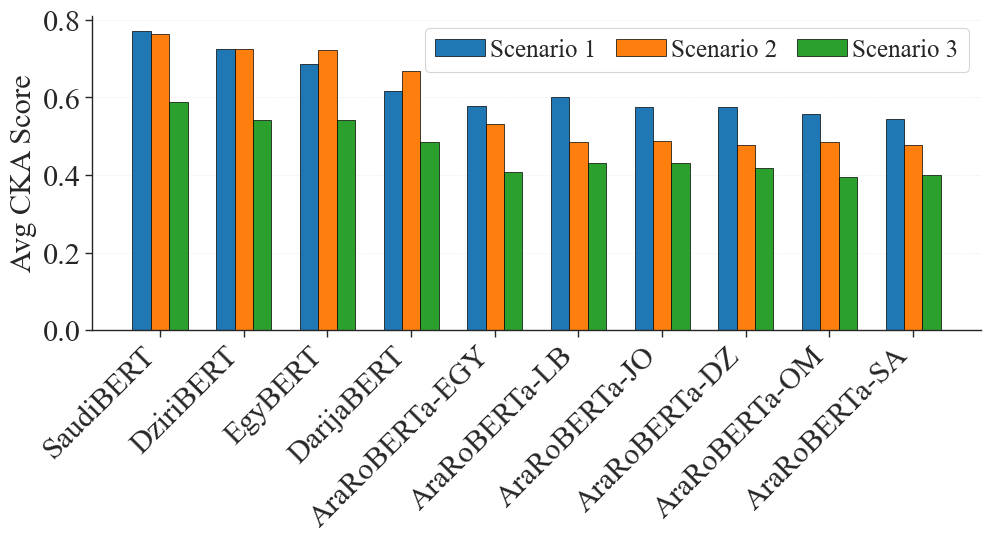

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_avg_cka_bar_grouped(
    data: pd.DataFrame, 
    scenario = ['msa_model(da) vs dialect_model(da)', 'msa_model(msa) vs dialect_model(msa)', 'msa_model(msa) vs dialect_model(da)']
):
    sns.set_style('ticks')
    sns.set_context('paper', font_scale=1.0)

    plt.rcParams["font.family"] = "Times New Roman"   # e.g., "Times New Roman", "Arial", "Noto Sans Arabic"
    
    # Nicer model names
    model_mapping = {
        'CAMeL-Lab/bert-base-arabic-camelbert-da': 'CAMeLBERT-DA',
        'CAMeL-Lab/bert-base-arabic-camelbert-mix': 'CAMeLBERT-MIX',
        'CAMeL-Lab/bert-base-arabic-camelbert-msa': 'CAMeLBERT-MSA',
        'SI2M-Lab/DarijaBERT': 'DarijaBERT',
        'alger-ia/dziribert': 'DziriBERT',
        'faisalq/EgyBERT': 'EgyBERT',
        'faisalq/SaudiBERT': 'SaudiBERT',
        'reemalyami/AraRoBERTa-DZ': 'AraRoBERTa-DZ',
        'reemalyami/AraRoBERTa-EGY': 'AraRoBERTa-EGY',
        'reemalyami/AraRoBERTa-JO': 'AraRoBERTa-JO',
        'reemalyami/AraRoBERTa-LB': 'AraRoBERTa-LB',
        'reemalyami/AraRoBERTa-OM': 'AraRoBERTa-OM',
        'reemalyami/AraRoBERTa-SA': 'AraRoBERTa-SA'
    }

    # Replace HF names with short names but keep others untouched
    df_local = data.copy()
    df_local['dialect_model'] = df_local['dialect_model'].replace(model_mapping)
    df_local = df_local[df_local["layer_i"] == df_local["layer_j"]]

    # Filter and aggregate: max F1 per (model, task) for the given dialect
    df = df_local[
        (df_local['scenario'].isin(scenario))
    ]

    df = (
        df.groupby(["dialect_model", "scenario"], as_index=False)["cka_score"]
          .mean()
    )

    # Pivot to models × tasks
    pivot = df.pivot(index='dialect_model', columns='scenario', values='cka_score')

    # Ensure tasks appear in requested order (and drop missing cols silently)
    pivot = pivot[[t for t in scenario if t in pivot.columns]]

    # Sort models by average F1 (optional)
    pivot['mean_cka'] = pivot.mean(axis=1, skipna=True)
    pivot = pivot.sort_values('mean_cka', ascending=False)
    pivot = pivot.drop(columns=['mean_cka'])

    models = pivot.index.tolist()
    x = np.arange(len(models))
    n_tasks = len(pivot.columns)

    # Bar width and offsets so they’re centered around each model
    width = 0.22
    offsets = (np.arange(n_tasks) - (n_tasks - 1) / 2) * width

    fig, ax = plt.subplots(figsize=(10, 5.5))

    # Color palette for tasks
    colors = sns.color_palette('tab10', n_tasks)

    # Plot one bar-series per task
    for i, task in enumerate(pivot.columns):
        heights = pivot[task].values
        ax.bar(
            x + offsets[i],
            heights,
            width=width,
            label=task,
            color=colors[i],
            edgecolor='black',
            linewidth=0.5,
        )

    # Axes & labels
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=22)
    ax.set_ylabel('Avg CKA Score', fontsize=22)
    ax.tick_params(axis='y', labelsize=22)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)

    # ax.set_title(f'Max F1 per Model and Task – {dialect}', fontsize=11, fontweight='bold')

    # Legend for tasks
    # ax.legend(title='Scenario', fontsize=9, title_fontsize=9, loc='best')
    ax.legend(fontsize=18, loc='best', ncol=len(ax.get_legend_handles_labels()[1]), columnspacing=0.80, handletextpad=0.20, frameon=True)

    sns.despine()
    plt.tight_layout()

    # Save as clear vector image (good for papers)
    plt.savefig(
        f'visualizations/avg_cka_all_scenario.png',
        format='png',
        bbox_inches='tight',
        dpi=300,
    )
    plt.show()

plot_avg_cka_bar_grouped(df_cka_detailed, scenario=['Scenario 1', 'Scenario 2', 'Scenario 3'])

# Geographical Proximity Analysis

In [48]:
import geopandas as gpd
from shapely.ops import unary_union
import json

def get_merged_morocco_geojson():
    # Download directly from Natural Earth — no dataset API required
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)

    # Note: full Natural Earth uses uppercase ISO_A3 column
    mar_esh = world[world["ISO_A3"].isin(["MAR", "ESH"])]
    merged_geom = unary_union(mar_esh.geometry)

    gdf = gpd.GeoDataFrame(
        {"id": ["MAR_MERGED"]},
        geometry=[merged_geom],
        crs="EPSG:4326"
    )
    return json.loads(gdf.to_json())

MOROCCO_GEOJSON = get_merged_morocco_geojson()  # call once

In [64]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px


def compute_marker_sizes(series, size_min=10, size_max=40):
    """Scale a numeric series to marker sizes."""
    s_min, s_max = series.min(), series.max()
    if s_min == s_max:
        return [(size_min + size_max) / 2.0] * len(series)
    return size_min + (series - s_min) / (s_max - s_min) * (size_max - size_min)

def plot_static_three_scores_map(df: pd.DataFrame, filename):
    meta_cols = {"lat", "long", "country", "model"}
    score_cols = [c for c in df.columns if c not in meta_cols]
    if len(score_cols) == 0:
        raise ValueError("No score columns found.")
    # score_cols = sorted(score_cols)

    yemen_coords = (16.3471243, 47.8915271)
    yemen_lat = yemen_coords[0]
    yemen_lon = yemen_coords[1]

    # Split into AraRoBERTa vs non-AraRoBERTa
    is_araro = df["model"].str.contains("AraRoBERTa", case=False, na=False)
    df_araro = df[is_araro].copy()
    df_araro["model"] = df_araro["model"].str.split('-').str[-1].str.upper()
    df_non_araro = df[~is_araro].copy()

    models_non_araro = df_non_araro["model"].unique().tolist()
    models_araro = df_araro["model"].unique().tolist()
    
    # Shared marker size scaling
    size_map = {}
    for sc in score_cols:
        size_map[sc] = pd.Series(
            compute_marker_sizes(df[sc]),
            index=df.index
        )

    # Color map per model
    all_models = df_non_araro["model"].unique().tolist() + df_araro["model"].unique().tolist()
    palette = sns.color_palette('tab10').as_hex()
    color_map = {m: palette[i % len(palette)] for i, m in enumerate(all_models)}

    column_titles = [c.replace("_", " ") for c in score_cols]
    row_titles = ["Non-AraRoBERTa models", "AraRoBERTa models"]

    fig = make_subplots(
        rows=2,
        cols=len(score_cols),
        specs=[[{"type": "geo"}] * len(score_cols) for _ in range(2)],
        horizontal_spacing=0.01,
        vertical_spacing=0.02,
        column_titles=column_titles,
    )

    LAND_COLOR = "rgb(240, 240, 240)"       # must match your landcolor in update_geos
    COUNTRY_LINE_COLOR = "#444"  # Plotly's default showcountries color
    COUNTRY_LINE_WIDTH = 1                   # match countrywidth

    def add_morocco_merged(row_idx: int, col_idx: int):
        fig.add_trace(
            go.Choropleth(
                geojson=MOROCCO_GEOJSON,
                locations=["MAR_MERGED"],
                featureidkey="properties.id",   # matches the "id" column in the GeoDataFrame
                z=[1],
                colorscale=[[0, LAND_COLOR], [1, LAND_COLOR]],
                showscale=False,
                marker_line_color=COUNTRY_LINE_COLOR,  # outer border visible, same style as other countries
                marker_line_width=COUNTRY_LINE_WIDTH,
                hoverinfo="skip",
            ),
            row=row_idx,
            col=col_idx,
        )

    def add_row_traces(df_sub, row_idx: int):
        """Real data traces (no legends here). Larger bubbles drawn first, smaller last."""
        if df_sub.empty:
            return

        for col_idx, score_col in enumerate(score_cols, start=1):
            pretty_sc = score_col.replace("_", " ").title()

            # --- NEW: order models by average bubble size (descending) for this score ---
            # So larger bubbles are drawn first, smaller on top.
            sizes_for_col = size_map[score_col].loc[df_sub.index]
            df_with_size = df_sub.assign(_size=sizes_for_col)
            model_order = (
                df_with_size
                .groupby("model")["_size"]
                .mean()
                .sort_values(ascending=False)  # largest -> smallest
                .index
                .tolist()
            )

            for model in model_order:
                sub_m = df_sub[df_sub["model"] == model]
                if sub_m.empty:
                    continue

                sizes_sub = size_map[score_col].loc[sub_m.index].tolist()
                customdata = np.stack(
                    [sub_m["model"], sub_m["country"], sub_m[score_col]],
                    axis=-1
                )

                fig.add_trace(
                    go.Scattergeo(
                        lon=sub_m["long"],
                        lat=sub_m["lat"],
                        mode="markers",
                        marker=dict(
                            size=[i*1.2 for i in sizes_sub],
                            sizemode="diameter",
                            opacity=1,
                            line=dict(width=1, color="black"),
                            color=color_map[model],
                        ),
                        name=model,
                        showlegend=False,  # legends are handled by dummy traces
                        hoverinfo="text",
                        customdata=customdata,
                        hovertemplate=(
                            "<b>%{customdata[0]}</b><br>"
                            "Country: %{customdata[1]}<br>"
                            f"{pretty_sc}: " + "%{customdata[2]:.3f}<br>"
                            "<extra></extra>"
                        ),
                    ),
                    row=row_idx,
                    col=col_idx,
                )

            # Yemen star
            fig.add_trace(
                go.Scattergeo(
                    lon=[yemen_lon],
                    lat=[yemen_lat],
                    mode="markers",
                    marker=dict(
                        size=18,
                        symbol="star",
                        color="black",
                        line=dict(width=1.5, color="black"),
                    ),
                    showlegend=False,
                    hoverinfo="skip",
                ),
                row=row_idx,
                col=col_idx,
            )

            fig.update_geos(
                projection_type="natural earth",
                showcountries=True,
                showland=True,
                landcolor="rgb(240, 240, 240)",
                lataxis_range=[5, 40],
                lonaxis_range=[-15, 65],
                row=row_idx,
                col=col_idx,
            )

            add_morocco_merged(row_idx=1, col_idx=col_idx)
            add_morocco_merged(row_idx=2, col_idx=col_idx)

    # Add real traces
    add_row_traces(df_non_araro, row_idx=1)
    add_row_traces(df_araro, row_idx=2)

    # Legend-only traces (fixed marker size, off-map)
    legend_marker_size = 50

    def add_legend_traces(models, legend_id: str):
        for model in models:
            fig.add_trace(
                go.Scattergeo(
                    lon=[0],
                    lat=[90],  # off visible area
                    mode="markers",
                    marker=dict(
                        size=legend_marker_size,
                        color=color_map[model],
                        line=dict(width=1, color="black"),
                    ),
                    name=model,
                    showlegend=True,
                    hoverinfo="skip",
                    legend=legend_id,   # <<< key line
                ),
                row=1,
                col=1,
            )

    add_legend_traces(models_non_araro, "legend")   # top legend block
    add_legend_traces(models_araro, "legend2")      # second legend block

    # Row titles horizontal on the left
    for ann in fig.layout.annotations:
        if ann.text in row_titles:
            ann.textangle = 0
            ann.xanchor = "left"
            ann.x = -0.08
        if ann.text in column_titles:
            ann.text = f"<b>{ann.text}</b>"
            ann.font = dict(size=25,family="Times New Roman") 

    # fig.update_layout(
    #     # title=dict(
    #     #     text="Scores per Country (Non-AraRoBERTa vs AraRoBERTa Models)",
    #     #     x=0.5,
    #     #     xanchor="center",
    #     # ),
    #     width=1500,
    #     height=100,
    #     margin=dict(l=10, r=230, t=40, b=10),
    #     hovermode="closest",
    #     legend=dict(
    #         x=1.05,
    #         xanchor="left",
    #         y=0.5,
    #         yanchor="middle",
    #         tracegroupgap=8,
    #     ),
    # )

    fig.update_layout(
        margin=dict(l=10, r=10, t=30, b=80),  # give room for two legend rows
        width=1500,
        height=100,
        hovermode="closest",
        legend=dict(
            title=dict(text="<b>BERT models</b>"),
            orientation="h",
            x=0.5, xanchor="center",
            y=-0.02, yanchor="top",
            itemsizing="trace",
        ),
        legend2=dict(
            title=dict(text="<b>AraRoBERTa models</b>"),
            orientation="h",
            x=0.5, xanchor="center",
            y=-0.14, yanchor="top",
            itemsizing="trace",
        ),
    )
    

    dpi = 96
    width_in = 10  # choose your desired print size
    height_in = 5

    width_px = int(width_in * dpi)
    height_px = int(height_in * dpi)

    fig.update_layout(
        font=dict(family="Times New Roman", size=25),
        autosize=False,
        width=width_px,
        height=height_px,
    )

    # Requires: pip install -U kaleido
    fig.write_image(
        filename,              # e.g., "map.png"
        format="svg",
        width=width_px,
        height=height_px,
        scale=1,
        engine="kaleido",
    )

    fig.show()

In [65]:
def summarize_probe_results(data, tasks = ['POS', 'NER', 'Sentiment'], dialect='MSA'):

    # Replace HF names with short names but keep others untouched
    df_local = data.copy()

    # Filter and aggregate: max F1 per (model, task) for the given dialect
    df = df_local[
        (df_local['dialect'] == dialect) &
        (df_local['task'].isin(tasks)) &
        (df_local['layer'] != 'all_layers')
    ]

    df = (
        df
        .groupby(['model', 'task'], as_index=False)
        .agg({'f1_overall': 'max'})
    )

    # Pivot to models × tasks
    pivot = df.pivot(index='model', columns='task', values='f1_overall')

    # Ensure tasks appear in requested order (and drop missing cols silently)
    pivot = pivot[[t for t in tasks if t in pivot.columns]]

    pivot = pivot.reset_index().rename_axis(None, axis=1)

    return pivot


def summarize_cka_results(data, scenario=['Scenario 1', 'Scenario 2', 'Scenario 3']):

        # Replace HF names with short names but keep others untouched
    df_local = data.copy()
    df_local = df_local[df_local["layer_i"] == df_local["layer_j"]]

    # Filter and aggregate: max F1 per (model, task) for the given dialect
    df = df_local[
        (df_local['scenario'].isin(scenario))
    ]

    df = (
        df.groupby(["dialect_model", "scenario"], as_index=False)["cka_score"]
          .mean()
    )

    # Pivot to models × tasks
    pivot = df.pivot(index='dialect_model', columns='scenario', values='cka_score')

    pivot = pivot.reset_index().rename_axis(None, axis=1)

    pivot = pivot.rename(columns={'dialect_model': 'model'})

    return pivot


def get_proximity_table():

    country_coords = {
        "Saudi": (25.6242618, 42.3528328),
        "Lebanon": (33.8750629, 35.843409),
        "Algeria": (28.0000272, 2.9999825),
        "Jordan": (31.1667049, 36.941628),
        "Morocco": (31.1728205, -7.3362482),
        "Egypt": (26.2540493, 29.2675469),
        "Oman": (21.0000287, 57.0036901),
    }

    model_country = {
        "faisalq/EgyBERT": "Egypt",
        "faisalq/SaudiBERT": "Saudi",
        "SI2M-Lab/DarijaBERT": "Morocco",
        "alger-ia/dziribert": "Algeria",
        "reemalyami/AraRoBERTa-SA": "Saudi",
        "reemalyami/AraRoBERTa-EGY": "Egypt",
        "reemalyami/AraRoBERTa-OM": "Oman",
        "reemalyami/AraRoBERTa-JO": "Jordan",
        "reemalyami/AraRoBERTa-LB": "Lebanon",
        "reemalyami/AraRoBERTa-DZ": "Algeria",
    }
    yemen_coords = (16.3471243, 47.8915271)


    proximity_models = summarize_probe_results(df_overall, dialect='MSA').merge(
                            summarize_cka_results(df_cka_detailed))
    
    proximity_models['country'] = [model_country[i] for i in proximity_models['model']]
    proximity_models['lat'] = [country_coords[model_country[i]][0] for i in proximity_models['model']]
    proximity_models['long'] = [country_coords[model_country[i]][1] for i in proximity_models['model']]

     # Nicer model names
    model_mapping = {
        'CAMeL-Lab/bert-base-arabic-camelbert-da': 'CAMeLBERT-DA',
        'CAMeL-Lab/bert-base-arabic-camelbert-mix': 'CAMeLBERT-MIX',
        'CAMeL-Lab/bert-base-arabic-camelbert-msa': 'CAMeLBERT-MSA',
        'SI2M-Lab/DarijaBERT': 'DarijaBERT',
        'alger-ia/dziribert': 'DziriBERT',
        'faisalq/EgyBERT': 'EgyBERT',
        'faisalq/SaudiBERT': 'SaudiBERT',
        'reemalyami/AraRoBERTa-DZ': 'AraRoBERTa-DZ',
        'reemalyami/AraRoBERTa-EGY': 'AraRoBERTa-EGY',
        'reemalyami/AraRoBERTa-JO': 'AraRoBERTa-JO',
        'reemalyami/AraRoBERTa-LB': 'AraRoBERTa-LB',
        'reemalyami/AraRoBERTa-OM': 'AraRoBERTa-OM',
        'reemalyami/AraRoBERTa-SA': 'AraRoBERTa-SA'
    }

    proximity_models = proximity_models.merge(size_df[['model', 'size_in_B']], on='model', how = 'left'
                                              ).sort_values('size_in_B', ascending=False
                                                            ).drop('size_in_B', axis = 1)

    proximity_models['model'] = proximity_models['model'].replace(model_mapping)

    return proximity_models

proximity_models = get_proximity_table()

In [66]:
df = proximity_models[['model', 'POS', 'NER', 'Sentiment','country', 'lat', 'long']]
plot_static_three_scores_map(df,"visualizations/Probing_Continuum.svg")

In [67]:
df = proximity_models[['model', 'Scenario 1', 'Scenario 2', 'Scenario 3','country', 'lat', 'long']]
plot_static_three_scores_map(df, 'visualizations/CKA_Continuum.svg')